In [46]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    TimeDistributed,
    Dropout
)
from collections import Counter

In [9]:
import os

DATA_PATH = "/kaggle/input/datasets/alaakhaled/conll003-englishversion/"
print(os.listdir(DATA_PATH))

['valid.txt', 'metadata', 'test.txt', 'train.txt']


In [10]:
def read_conll(file_path):
    sentences = []
    labels = []

    sentence = []
    tag = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:

            line = line.strip()

            if line == "":
                if sentence:
                    sentences.append(sentence)
                    labels.append(tag)
                    sentence = []
                    tag = []
                continue

            parts = line.split()

            word = parts[0]
            ner = parts[-1]

            sentence.append(word)
            tag.append(ner)

    return sentences, labels

In [12]:
train_sentences, train_labels = read_conll(DATA_PATH + "train.txt")
valid_sentences, valid_labels = read_conll(DATA_PATH + "valid.txt")
test_sentences, test_labels = read_conll(DATA_PATH + "test.txt")

In [13]:
print(train_sentences[0])
print(train_labels[0])

['-DOCSTART-']
['O']


In [14]:
print("Train:", len(train_sentences))
print("Validation:", len(valid_sentences))
print("Test:", len(test_sentences))

Train: 14987
Validation: 3466
Test: 3684


In [15]:

all_tags = [tag for sentence in train_labels for tag in sentence]

tag_counter = Counter(all_tags)

print(tag_counter)

Counter({'O': 170524, 'B-LOC': 7140, 'B-PER': 6600, 'B-ORG': 6321, 'I-PER': 4528, 'I-ORG': 3704, 'B-MISC': 3438, 'I-LOC': 1157, 'I-MISC': 1155})


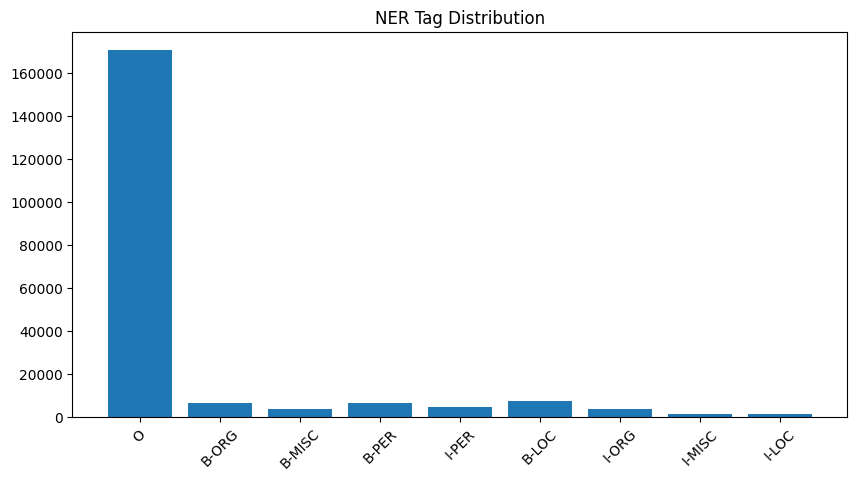

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(tag_counter.keys(), tag_counter.values())

plt.xticks(rotation=45)

plt.title("NER Tag Distribution")

plt.show()

In [17]:
sentence_lengths = [len(s) for s in train_sentences]

print("Min Length :", min(sentence_lengths))
print("Max Length :", max(sentence_lengths))
print("Average Length :", sum(sentence_lengths)/len(sentence_lengths))

Min Length : 1
Max Length : 113
Average Length : 13.649629679055181


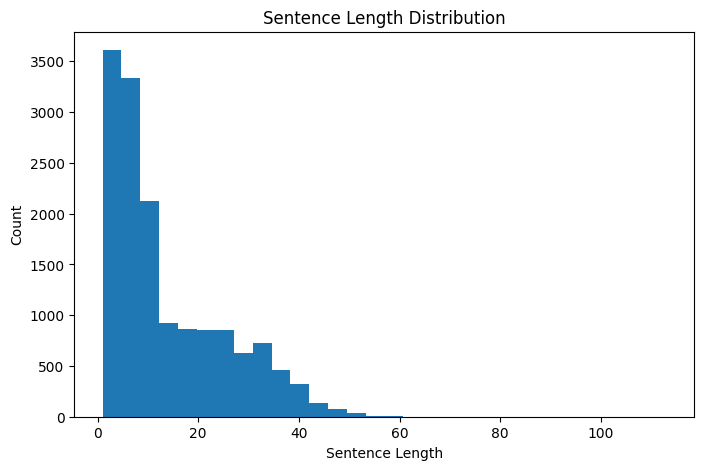

In [18]:
plt.figure(figsize=(8,5))

plt.hist(sentence_lengths, bins=30)

plt.title("Sentence Length Distribution")

plt.xlabel("Sentence Length")

plt.ylabel("Count")

plt.show()

In [19]:

all_words = [word for sentence in train_sentences for word in sentence]

word_counter = Counter(all_words)

print(word_counter.most_common(20))

[('.', 7374), (',', 7290), ('the', 7243), ('of', 3751), ('in', 3398), ('to', 3382), ('a', 2994), ('(', 2861), (')', 2861), ('and', 2838), ('"', 2178), ('on', 2040), ('said', 1846), ("'s", 1536), ('for', 1421), ('1', 1421), ('-', 1243), ('The', 1127), ('was', 1095), ('2', 973)]


In [20]:
unique_labels = sorted(set(tag for sentence in train_labels for tag in sentence))

print(unique_labels)

['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [21]:
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(label2id)

{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8}


In [22]:
train_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in train_labels
]

valid_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in valid_labels
]

test_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in test_labels
]

In [23]:
print(train_labels[0])
print(train_labels_ids[0])

['O']
[8]


In [24]:
all_words = [word for sentence in train_sentences for word in sentence]

print("Total Words:", len(all_words))
print("Unique Words:", len(set(all_words)))

Total Words: 204567
Unique Words: 23624


In [25]:
vocab = sorted(set(all_words))

word2id = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in vocab:
    word2id[word] = len(word2id)

id2word = {idx: word for word, idx in word2id.items()}

In [28]:
print("Vocabulary Size:", len(word2id))

print(word2id["John"])

print(word2id["google"])

Vocabulary Size: 23626
8342


KeyError: 'google'

"google isn't exit in training sentence"

In [29]:
word2id["<UNK>"]

1

In [30]:
train_ids = [
    [word2id.get(word, word2id["<UNK>"]) for word in sentence]
    for sentence in train_sentences
]

valid_ids = [
    [word2id.get(word, word2id["<UNK>"]) for word in sentence]
    for sentence in valid_sentences
]

test_ids = [
    [word2id.get(word, word2id["<UNK>"]) for word in sentence]
    for sentence in test_sentences
]

In [31]:
print(train_sentences[0])

print(train_ids[0])

['-DOCSTART-']
[125]


In [32]:
max_len = max(len(sentence) for sentence in train_ids)

print("Maximum sentence length:", max_len)

Maximum sentence length: 113


In [35]:
X_train = pad_sequences(
    train_ids,
    maxlen=max_len,
    padding="post",
    value=word2id["<PAD>"]
)

X_valid = pad_sequences(
    valid_ids,
    maxlen=max_len,
    padding="post",
    value=word2id["<PAD>"]
)

X_test = pad_sequences(
    test_ids,
    maxlen=max_len,
    padding="post",
    value=word2id["<PAD>"]
)

In [36]:
y_train = pad_sequences(
    train_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["O"]
)

y_valid = pad_sequences(
    valid_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["O"]
)

y_test = pad_sequences(
    test_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["O"]
)

In [37]:
print(X_train.shape)
print(y_train.shape)

print(X_valid.shape)
print(y_valid.shape)

print(X_test.shape)
print(y_test.shape)

(14987, 113)
(14987, 113)
(3466, 113)
(3466, 113)
(3684, 113)
(3684, 113)


In [38]:
print(X_train[0])
print(y_train[0])

[125   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0]
[8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8
 8 8]


In [39]:
label2id = {label: idx for idx, label in enumerate(unique_labels)}

In [40]:
unique_labels = sorted(set(tag for sentence in train_labels for tag in sentence))

unique_labels.append("<PAD>")

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

print(label2id)

{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8, '<PAD>': 9}


In [41]:
train_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in train_labels
]

valid_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in valid_labels
]

test_labels_ids = [
    [label2id[label] for label in sentence]
    for sentence in test_labels
]

In [42]:
value=label2id["O"]

In [43]:
y_train = pad_sequences(
    train_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["<PAD>"]
)

y_valid = pad_sequences(
    valid_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["<PAD>"]
)

y_test = pad_sequences(
    test_labels_ids,
    maxlen=max_len,
    padding="post",
    value=label2id["<PAD>"]
)

In [44]:
print(label2id)

print(y_train[0][-10:])

{'B-LOC': 0, 'B-MISC': 1, 'B-ORG': 2, 'B-PER': 3, 'I-LOC': 4, 'I-MISC': 5, 'I-ORG': 6, 'I-PER': 7, 'O': 8, '<PAD>': 9}
[9 9 9 9 9 9 9 9 9 9]


In [47]:
VOCAB_SIZE = len(word2id)
NUM_CLASSES = len(label2id)

EMBEDDING_DIM = 128
LSTM_UNITS = 128

In [48]:
inputs = Input(shape=(max_len,))

x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(inputs)

x = LSTM(
    LSTM_UNITS,
    return_sequences=True
)(x)

x = Dropout(0.3)(x)

outputs = TimeDistributed(
    Dense(NUM_CLASSES, activation="softmax")
)(x)

model = Model(inputs, outputs)

I0000 00:00:1784852123.550142      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784852123.553028      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [49]:
mask_zero=True

In [50]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 113)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 113, 128)  │  3,024,128 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 113)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 113, 128)  │    131,584 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 113, 128)  │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 113, 10)   │      1,290 │ dropout[0][0],    │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,157,002 (12.04 MB)

 Trainable params: 3,157,002 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
import numpy as np

y_train = np.expand_dims(y_train, axis=-1)
y_valid = np.expand_dims(y_valid, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

In [53]:
print(X_train.shape)
print(y_train.shape)

(14987, 113)
(14987, 113, 1)


In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [55]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=32,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8550 - loss: 0.5578 - val_accuracy: 0.8940 - val_loss: 0.3895
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9389 - loss: 0.2103 - val_accuracy: 0.9454 - val_loss: 0.2286
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9796 - loss: 0.0835 - val_accuracy: 0.9456 - val_loss: 0.1887
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9878 - loss: 0.0448 - val_accuracy: 0.9484 - val_loss: 0.1836
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9911 - loss: 0.0306 - val_accuracy: 0.9367 - val_loss: 0.2076
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9930 - loss: 0.0234 - val_accuracy: 0.9462 - val_loss: 0.2000
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9942 - loss: 0.0187 - val_accuracy: 0.9434 - val_loss: 0.2123


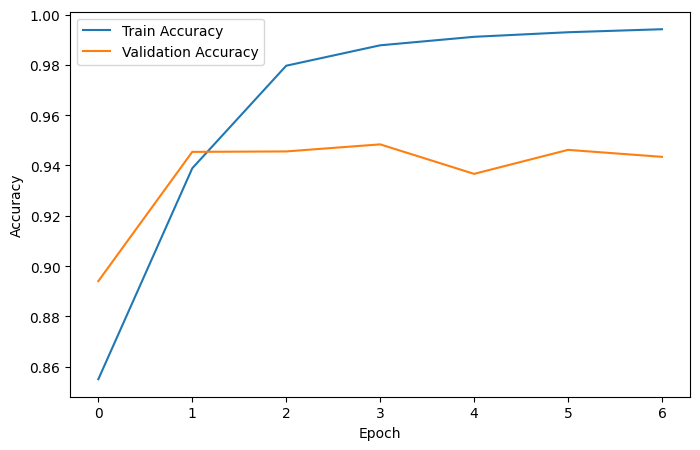

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

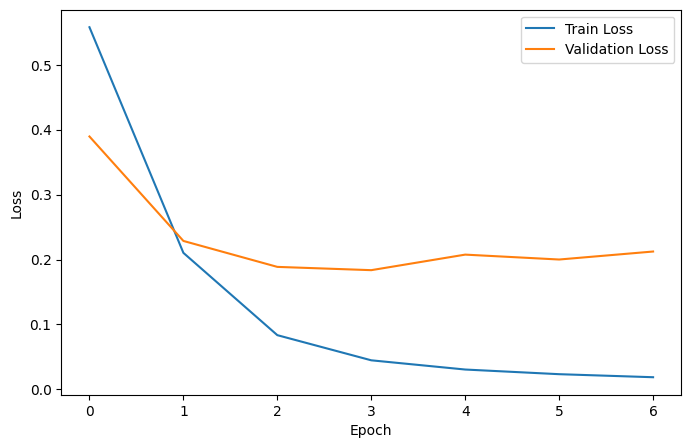

In [57]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [58]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9237 - loss: 0.2934
Test Loss: 0.2933906614780426
Test Accuracy: 0.9237377643585205


In [59]:
model.save("ner_lstm.keras")

In [60]:
y_pred = model.predict(X_tes

116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


In [61]:
import numpy as np

y_pred_ids = np.argmax(y_pred, axis=-1)

In [62]:
def ids_to_labels(ids, id2label):
    return [[id2label[idx] for idx in sentence] for sentence in ids]

In [63]:
true_labels = ids_to_labels(
    np.squeeze(y_test, axis=-1),
    id2label
)

In [64]:
pred_labels = ids_to_labels(
    y_pred_ids,
    id2label
)

In [65]:
def remove_padding(true_labels, pred_labels):

    true_clean = []
    pred_clean = []

    for true_sent, pred_sent in zip(true_labels, pred_labels):

        t = []
        p = []

        for true_tag, pred_tag in zip(true_sent, pred_sent):

            if true_tag != "<PAD>":

                t.append(true_tag)
                p.append(pred_tag)

        true_clean.append(t)
        pred_clean.append(p)

    return true_clean, pred_clean

In [67]:
true_clean, pred_clean = remove_padding(
    true_labels,
    pred_labels
)

In [74]:
from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Precision :", precision_score(true_clean, pred_clean))
print("Recall    :", recall_score(true_clean, pred_clean))
print("F1 Score  :", f1_score(true_clean, pred_clean))

Precision : 0.6360208295923864
Recall    : 0.6274579273693535
F1 Score  : 0.6317103620474407


In [75]:
print(classification_report(true_clean, pred_clean))

              precision    recall  f1-score   support

         LOC       0.64      0.74      0.69      1667
        MISC       0.42      0.64      0.51       702
         ORG       0.64      0.56      0.60      1660
         PER       0.82      0.57      0.67      1616

   micro avg       0.64      0.63      0.63      5645
   macro avg       0.63      0.63      0.62      5645
weighted avg       0.67      0.63      0.64      5645



In [76]:
from tensorflow.keras.layers import Bidirectional

x = Bidirectional(
    LSTM(
        LSTM_UNITS,
        return_sequences=True
    )
)(x)

In [77]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dropout,
    Dense,
    TimeDistributed
)

In [78]:
inputs = Input(shape=(max_len,))

x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(inputs)

x = Bidirectional(
    LSTM(
        LSTM_UNITS,
        return_sequences=True
    )
)(x)

x = Dropout(0.3)(x)

outputs = TimeDistributed(
    Dense(NUM_CLASSES, activation="softmax")
)(x)

bilstm_model = Model(inputs, outputs)

In [79]:
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [80]:
bilstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 113)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 113, 128)  │  3,024,128 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 113)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 113, 256)  │    263,168 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 113, 256)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 113, 10)   │      2,570 │ dropout_1[0][0],  │
│ (TimeDistributed)   │                   │            │ not_equal_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,289,866 (12.55 MB)

 Trainable params: 3,289,866 (12.55 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9963 - loss: 0.0132 - val_accuracy: 0.9628 - val_loss: 0.1514
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9977 - loss: 0.0082 - val_accuracy: 0.9620 - val_loss: 0.1668
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9985 - loss: 0.0054 - val_accuracy: 0.9609 - val_loss: 0.1754
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9608 - val_loss: 0.1976


In [84]:
loss, accuracy = bilstm_model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9387 - loss: 0.2797
Test Loss: 0.27966469526290894
Test Accuracy: 0.9386772513389587


In [85]:
y_pred = bilstm_model.predict(X_test)

y_pred_ids = np.argmax(y_pred, axis=-1)

116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


In [86]:
true_labels = ids_to_labels(
    np.squeeze(y_test, axis=-1),
    id2label
)

pred_labels = ids_to_labels(
    y_pred_ids,
    id2label
)

In [88]:
true_clean, pred_clean = remove_padding(
    true_labels,
    pred_labels
)

In [89]:
from seqeval.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Precision :", precision_score(true_clean, pred_clean))
print("Recall    :", recall_score(true_clean, pred_clean))
print("F1 Score  :", f1_score(true_clean, pred_clean))

print(classification_report(true_clean, pred_clean))

Precision : 0.6960714285714286
Recall    : 0.6905225863596103
F1 Score  : 0.6932859048465986
              precision    recall  f1-score   support

         LOC       0.85      0.78      0.82      1667
        MISC       0.67      0.67      0.67       702
         ORG       0.67      0.65      0.66      1660
         PER       0.59      0.64      0.62      1616

   micro avg       0.70      0.69      0.69      5645
   macro avg       0.70      0.69      0.69      5645
weighted avg       0.70      0.69      0.70      5645



In [90]:
bilstm_model.save("ner_bilstm.keras")

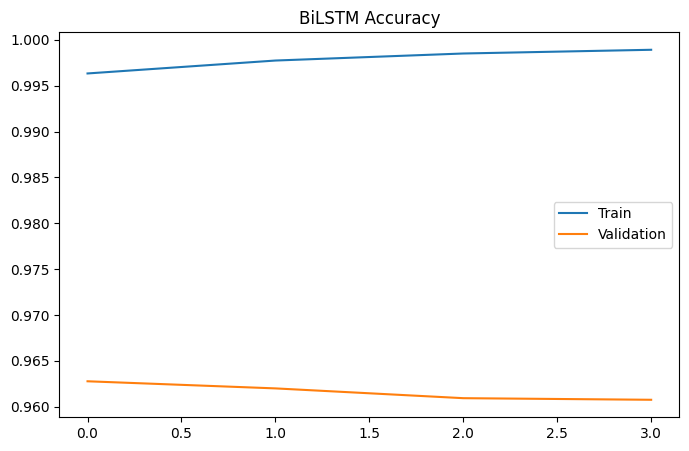

In [91]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_bilstm.history["accuracy"], label="Train")

plt.plot(history_bilstm.history["val_accuracy"], label="Validation")

plt.legend()

plt.title("BiLSTM Accuracy")

plt.show()

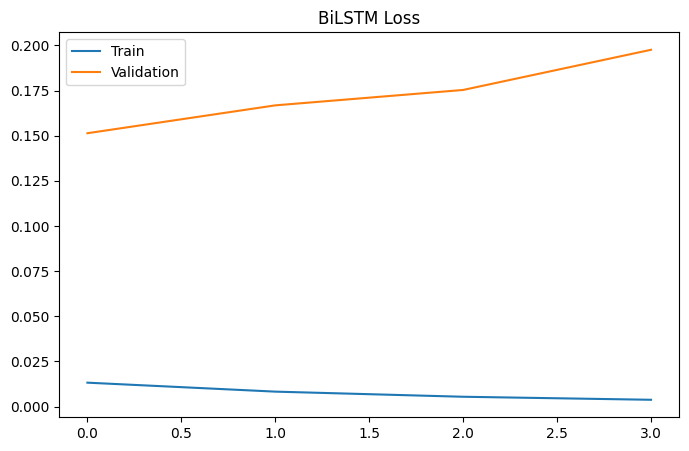

In [92]:
plt.figure(figsize=(8,5))

plt.plot(history_bilstm.history["loss"], label="Train")

plt.plot(history_bilstm.history["val_loss"], label="Validation")

plt.legend()

plt.title("BiLSTM Loss")

plt.show()

In [93]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [98]:
from torchcrf import CRF

In [99]:
X_train = torch.LongTensor(X_train)
X_valid = torch.LongTensor(X_valid)
X_test = torch.LongTensor(X_test)

y_train = torch.LongTensor(y_train.squeeze(-1))
y_valid = torch.LongTensor(y_valid.squeeze(-1))
y_test = torch.LongTensor(y_test.squeeze(-1))

In [100]:
class NERDataset(Dataset):

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [102]:
train_dataset = NERDataset(X_train, y_train)
valid_dataset = NERDataset(X_valid, y_valid)
test_dataset = NERDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [103]:
!pip install transformers datasets seqeval -q

In [104]:
import numpy as np

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)

from seqeval.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [107]:
train_dataset = Dataset.from_dict({
    "tokens": train_sentences,
    "ner_tags": train_labels_ids
})

valid_dataset = Dataset.from_dict({
    "tokens": valid_sentences,
    "ner_tags": valid_labels_ids
})

test_dataset = Dataset.from_dict({
    "tokens": test_sentences,
    "ner_tags": test_labels_ids
})

In [108]:
checkpoint = "distilbert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [109]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples["ner_tags"]):

        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None

        label_ids = []

        for word_idx in word_ids:

            if word_idx is None:
                label_ids.append(-100)

            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])

            else:
                label_ids.append(label[word_idx])

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels

    return tokenized_inputs

In [110]:
tokenized_train = train_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

tokenized_valid = valid_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_and_align_labels,
    batched=True
)

Map:   0%|          | 0/14987 [00:00<?, ? examples/s]

Map:   0%|          | 0/3466 [00:00<?, ? examples/s]

Map:   0%|          | 0/3684 [00:00<?, ? examples/s]

In [111]:
model = AutoModelForTokenClassification.from_pretrained(
    checkpoint,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [113]:
data_collator = DataCollatorForTokenClassification(tokenizer)

In [116]:
!pip install evaluate -q

In [117]:
import evaluate

seqeval = evaluate.load("seqeval")

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=2)

    true_predictions = []
    true_labels = []

    for prediction, label in zip(predictions, labels):

        current_predictions = []
        current_labels = []

        for p, l in zip(prediction, label):

            if l != -100:

                current_predictions.append(id2label[p])
                current_labels.append(id2label[l])

        true_predictions.append(current_predictions)
        true_labels.append(current_labels)

    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [118]:
training_args = TrainingArguments(
    output_dir="./bert_ner",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    logging_steps=100,

    report_to="none"
)

In [120]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

In [121]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.245289,0.199252,0.873965,0.890275,0.882044,0.971538
2,0.142080,0.159574,0.904787,0.908846,0.906812,0.977728
3,0.089301,0.153977,0.914349,0.920420,0.917375,0.979744


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1407, training_loss=0.2507796144561727, metrics={'train_runtime': 214.5104, 'train_samples_per_second': 209.598, 'train_steps_per_second': 6.559, 'total_flos': 619196413272720.0, 'train_loss': 0.2507796144561727, 'epoch': 3.0})

In [122]:
metrics = trainer.evaluate(tokenized_test)

print(metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.32621657848358154, 'eval_precision': 0.8606430458147373, 'eval_recall': 0.8766119306058076, 'eval_f1': 0.8685540950455004, 'eval_accuracy': 0.9641507114539476, 'eval_runtime': 6.8917, 'eval_samples_per_second': 534.557, 'eval_steps_per_second': 16.832, 'epoch': 3.0}


In [123]:
trainer.save_model("distilbert_ner")

tokenizer.save_pretrained("distilbert_ner")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_ner/tokenizer_config.json', 'distilbert_ner/tokenizer.json')

In [124]:
import shutil

shutil.make_archive(
    "distilbert_ner",
    "zip",
    "/kaggle/working/distilbert_ner"
)

'/kaggle/working/distilbert_ner.zip'